#Universidad Nacional Autónoma de México
#Facultad de Ingeniería
#División de Ingeniería Mecánica e Industrial
##Robótica G1 2026_2
###Profesor: M.I Erik Peña Medina
###Alumno: Fabian Ortiz Carreño

# **Introducción**

El modelado de un robot no es solo una tarea matemática; representa el primer paso crítico para cualquier aplicación de ingeniería real, ya sea que hablemos de una simulación precisa o del diseño de un sistema de control robusto.En este reporte, el objetivo es consolidar esos conceptos mediante el estudio exhaustivo de un robot tipo SCARA de tres eslabones, analizando su comportamiento desde la geometría básica hasta las fuerzas más complejas que rigen su movimiento.

El análisis comienza con el estudio de la cinemática de la postura, donde se desarrolla el cálculo del vector de posiciones y se resuelve el modelo inverso para determinar la configuración necesaria del robot en su espacio de trabajo. Posteriormente, se escala hacia el modelado cinemático de velocidades y aceleraciones. En estas secciones, el enfoque principal es demostrar cómo las variables articulares se traducen en el movimiento del efector final, proyectando de manera sistemática las contribuciones tangenciales y normales de cada eslabón desde la base hasta el punto P de interés.

En la etapa más robusta del reporte, se aborda el modelo dinámico mediante el formalismo de Eüler-Lagrange. Aquí, la razón de ser del análisis es comprender la naturaleza física del robot: obtenemos la matriz de inercia y los vectores de fuerzas de Coriolis, centrífugas y de gravedad que conforman el modelo dinámico directo. Este proceso no es solo una acumulación de términos, sino una representación de cómo la energía se distribuye en el sistema; permitiéndonos ver cómo la masa y la velocidad de cada eslabón afectan el esfuerzo que deben realizar los actuadores.

Finalmente, se deriva el modelo dinámico inverso, el cual es la pieza clave para la toma de decisiones en ingeniería, ya que nos permite calcular los torques requeridos o las fuerzas de restricción en función del movimiento deseado. En conjunto, este desarrollo integral no solo cumple con los requerimientos del curso, sino que nos proporciona la estructura necesaria para predecir, simular y gestionar el comportamiento de un manipulador ante cualquier tarea de precisión o interacción con su entorno.


# **Modelado cinemático de la postura del robot**
Para iniciar este análisis, es necesario establecer la configuración geométrica de nuestro manipulador de estudio. En la figura 1 se presenta el diagrama cinemático, donde se identifican los eslabones y las variables articulares que definen su movimiento.



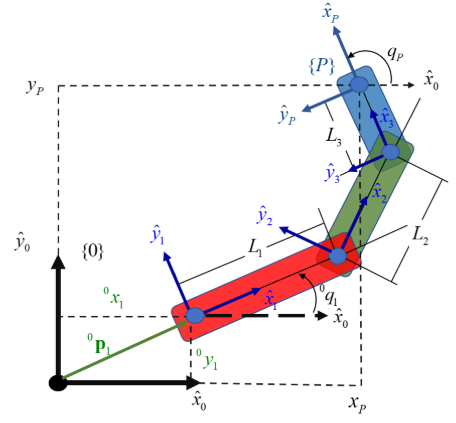


**Figura 1. Diagrama cinemático del robot SCARA RRR.**

Donde vemos que:
* **Variables articulares ($q$):** Definidas por los ángulos de rotación $\theta_1$, $\theta_2$ y $\theta_3$. Cada una de estas variables representa el grado de libertad de cada eslabón respecto al anterior.
* **Parámetros constantes ($L$):** Representan las longitudes físicas de los eslabones $L_1$, $L_2$ y $L_3$ (siendo este último la distancia al efector final).
* **Sistemas de referencia:** Se observa la asignación de marcos de referencia locales mediante la composición de transformaciones. Estos marcos permiten describir la posición y orientación final del robot en el espacio de la tarea.

## **Modelado cinemático directo**
Para obtener la postura del robot SCARA RRR, se realiza la composición de transformaciones homogéneas. Cada matriz representa el movimiento relativo entre eslabones considerando rotaciones en el eje $z$ y traslaciones en el plano horizontal.

<div align = "center">

${}^{0}T_{1} =
\left(\begin{array}{cccc}
\cos\left({}^{0}\theta_{1}\right) & -\sin\left({}^{0}\theta_{1}\right) & 0 & {}^{0}x_{1} \\
\sin\left({}^{0}\theta_{1}\right) & \cos\left({}^{0}\theta_{1}\right) & 0 & {}^{0}y_{1} \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{1}T_{2} =
\left(\begin{array}{cccc}
\cos \left({}^{1}\theta_{2} \right) & -\sin \left({}^{1}\theta_{2} \right) & 0 & L_1 \\
\sin \left({}^{1}\theta_{2} \right) & \cos \left({}^{1}\theta_{2} \right) & 0 & 0\\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{2}T_{3} =
\left(\begin{array}{cccc}
\cos \left({}^{2}\theta_{3} \right) & -\sin \left({}^{2}\theta_{3} \right) & 0 & L_2 \\
\sin \left({}^{2}\theta_{3} \right) & \cos \left({}^{2}\theta_{3} \right) & 0 & 0\\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{3}T_{P} =
\left(\begin{array}{cccc}
1 & 0 & 0 & L_3 \\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)$

</div>

<div align = "center">

${}^{0}T_{P} = {}^{0}T_{1} * {}^{1}T_{2} * {}^{2}T_{3} * {}^{3}T_{P} = $

$\begin{array}{l}
\left(\begin{array}{cccc}
\sigma_2  & -\sigma_1  & 0 & {}^{0}x_{1} + L_2 \cos\left({}^{0}\theta_{1} + {}^{1}\theta_{2}\right) + L_1 \cos\left({}^{0}\theta_{1}\right) + L_3 \sigma_2 \\
\sigma_1  & \sigma_2   & 0 & {}^{0}y_{1} + L_2 \sin\left({}^{0}\theta_{1} + {}^{1}\theta_{2}\right) + L_1 \sin\left({}^{0}\theta_{1}\right) + L_3 \sigma_1 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{array}\right) \\
\\
\textrm{where} \\
\\
\;\;\sigma_1 = \sin\left({}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3}\right) \\
\\
\;\;\sigma_2 = \cos\left({}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3}\right)
\end{array}$

### Vector de posturas del robot

El vector de posturas ${}^0\xi_{P}(q)$ describe la posición cartesiana $(x, y)$ del efector final y su orientación global respecto al sistema de referencia inercial $\{0\}$. Estos valores se extraen directamente de la matriz de transformación homogénea global ${}^0T_{P}$.

${}^{0}\xi_{P}(q) = $

$\left(\begin{array}{c}
{}^{0}x_{1} +L_2 \,\cos \left({}^{0}\theta_{1} + {}^{1}\theta_{2} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)+L_3 \,\cos \left({}^{0}\theta_{1} +{}^{1}\theta_{2} +{}^{2}\theta_{3} \right)\\
{}^{0}y_{1} +L_2 \,\sin \left({}^{0}\theta_{1} +{}^{1}\theta_{2} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)+L_3 \,\sin \left({}^{0}\theta_{1} +{}^{1}\theta_{2} +{}^{2}\theta_{3} \right)\\
{}^{0}\theta_{1} +{}^{1}\theta_{2} +{}^{2}\theta_{3}
\end{array}\right)$

</div>

## **Modelo cinemático Inverso**





El objetivo de la cinemática inversa es encontrar los valores articulares $q = [{}^{0}\theta_1, {}^{1}\theta_2, {}^{2}\theta_3]^T$ requeridos para posicionar y orientar el efector final en una pose deseada ${}^0\xi_P = [x_P, y_P, \theta_P]^T$ (De externo a interno).


Partiendo del modelo cinemático directo, se iguala el vector de postura deseado con las ecuaciones del sistema:

<div align="center">

${}^0\xi_P = {}^0\xi_P(q)$

$\begin{pmatrix} x_P \\ y_P \\ \theta_P \end{pmatrix} = \begin{pmatrix} {}^{0}x_{1} + L_2 \cos({}^{0}\theta_{1} + {}^{1}\theta_{2}) + L_1 \cos({}^{0}\theta_{1}) + L_3 \cos({}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3}) \\ {}^{0}y_{1} + L_2 \sin({}^{0}\theta_{1} + {}^{1}\theta_{2}) + L_1 \sin({}^{0}\theta_{1}) + L_3 \sin({}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3}) \\ {}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3} \end{pmatrix}$

</div>

Al intentar despejar las variables articulares, nos encontramos con un sistema fuertemente acoplado. Como las ecuaciones del vector no pueden ser despejadas directamente por no ser lineales, su solución general requeriría de métodos numéricos iterativos.

Para evitar el alto costo computacional de los métodos numéricos y encontrar soluciones analíticas exactas (restringidas a las limitaciones físicas del robot), se procede a utilizar un enfoque geométrico.



### Solución por Método Geométrico
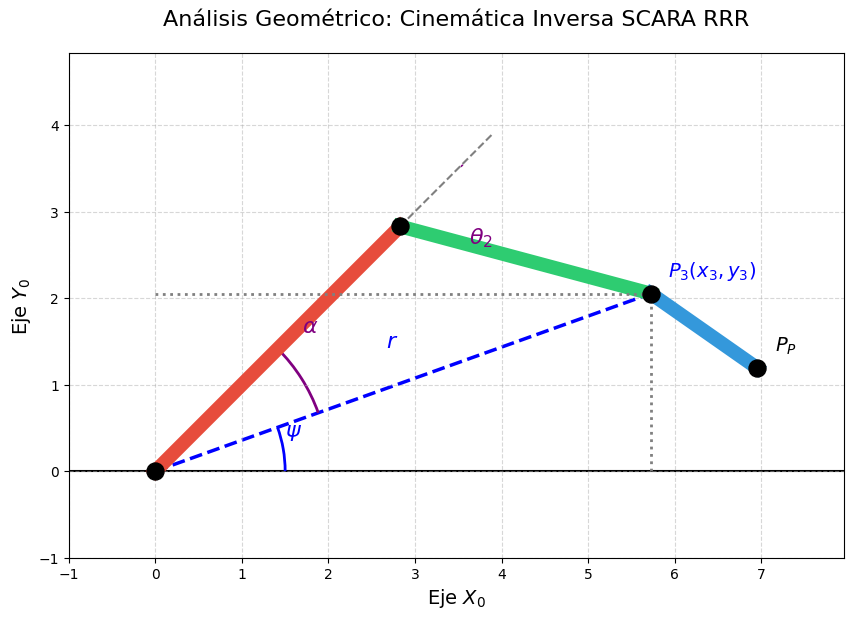

<p align="center">
  <b>Figura 2.</b> Análisis geométrico para la cinemática inversa del robot SCARA RRR. Se ilustra el desacoplamiento de la muñeca ($P_3$), el vector radial ($r$) y los ángulos auxiliares ($\psi, \alpha$) requeridos para la resolución de las articulaciones mediante la Ley de Cosenos.
</p>

El sistema RRR plano permite desacoplar la posición de la orientación. Aislando la tercera articulación (muñeca), reducimos el problema a un manipulador de dos eslabones, el cual se resuelve mediante la Ley de Cosenos.

**1. Desacoplamiento de la Muñeca ($P_3$)**
Calculamos las coordenadas de la articulación 3 restando la contribución del último eslabón $L_3$:
* ${}^0x_3 = x_P - {}^{0}x_{1} - L_3 \cos(\theta_P)$
* ${}^0y_3 = y_P - {}^{0}y_{1} - L_3 \sin(\theta_P)$

**2. Resolución de las Articulaciones 1 y 2 (Hombro y Codo)**
Trazando un vector radial $r$ desde el origen de la base hasta la muñeca, obtenemos $r = \sqrt{({}^0x_3)^2 + ({}^0y_3)^2}$. Aplicando trigonometría sobre el triángulo formado por $L_1$, $L_2$ y $r$:

* Ángulo del Codo (${}^{1}\theta_2$):
  $$\beta = \cos^{-1}\left(\frac{L_1^2 + L_2^2 - r^2}{2 L_1 L_2}\right)$$
  $${}^{1}\theta_2 = \pi - \beta$$ *(Considerando la configuración de codo abajo/arriba según el signo)*

* Ángulo de la Base (${}^{0}\theta_1$):
  $$\alpha = \cos^{-1}\left(\frac{L_1^2 + r^2 - L_2^2}{2 L_1 r}\right)$$
  $$\psi = \text{atan2}({}^0y_3, {}^0x_3)$$
  $${}^{0}\theta_1 = \psi \pm \alpha$$

**3. Orientación Final (${}^{2}\theta_3$)**
Finalmente, como la orientación en el plano es la suma algebraica de los giros, despejamos la tercera articulación:
* $${}^{2}\theta_3 = \theta_P - {}^{0}\theta_1 - {}^{1}\theta_2$$

### Resultado Final: Modelo Cinemático Inverso Analítico

Para cualquier punto objetivo definido por el vector de postura ${}^0\xi_P = [x_P, y_P, \theta_P]^T$, la configuración de las articulaciones $q = [{}^0\theta_1, {}^1\theta_2, {}^2\theta_3]^T$ se obtiene mediante las siguientes ecuaciones cerradas:

$$q = \begin{pmatrix}
{}^0\theta_1 \\
{}^1\theta_2 \\
{}^2\theta_3
\end{pmatrix} =
\begin{pmatrix}
\text{atan2}({}^0y_3, {}^0x_3) \pm \cos^{-1}\left(\frac{L_1^2 + r^2 - L_2^2}{2 L_1 r}\right) \\
\pi - \cos^{-1}\left(\frac{L_1^2 + L_2^2 - r^2}{2 L_1 L_2}\right) \\
\theta_P - {}^0\theta_1 - {}^1\theta_2
\end{pmatrix}$$


#### Variables intermedias de cálculo

Para resolver el sistema anterior, es necesario calcular previamente los siguientes parámetros geométricos:

*Coordenadas de la muñeca ($P_3$):**
    * ${}^0x_3 = x_P - {}^0x_1 - L_3 \cos(\theta_P)$
    * ${}^0y_3 = y_P - {}^0y_1 - L_3 \sin(\theta_P)$
* Radio efectivo ($r$): Distancia euclidiana desde la base hasta la articulación 3.
    * $r = \sqrt{({}^0x_3)^2 + ({}^0y_3)^2}$

Nota: La solución para ${}^0\theta_1$ presenta un signo $\pm$, lo que indica la existencia de dos configuraciones posibles (codo arriba y codo abajo) para alcanzar el mismo punto en el espacio de trabajo.

## **Cinemática de Velocidades**



### **Modelado cinemático directo**
Se definen los vectores de velocidad del efector y de las articulaciones como:

<div align = "center">

$\dot{{}^{0}\xi_{P}} = $
$\left(\begin{array}{c}
\dot{{}^{0}x_{P}} \\
\dot{{}^{0}y_{P}} \\
\dot{{}^{0}\theta_{P}}
\end{array}\right)$

$\dot{q} = $
$\left(\begin{array}{c}
\dot{{}^{0}\theta_{1}} \\
\dot{{}^{1}\theta_{2}} \\
\dot{{}^{2}\theta_{3}}
\end{array}\right)$
</div>

La relación entre ambos espacios está regida por la matriz Jacobiana  Jθ(q) , obtenida mediante el cálculo de las derivadas parciales del vector de postura respecto a las coordenadas articulares:

<div align = "center">
$\dot{{}^{0}\xi_{P}} = J_\theta(q)\dot{q} = $

$\begin{array}{l}
\left(\begin{array}{ccc}
-L_2 \,\sin \left({}^{0}\theta_{1} + {}^{1}\theta_{2} \right) - L_1 \,\sin \left({}^{0}\theta_{1} \right)-\sigma_1  & - L_2 \,\sin \left({}^{0}\theta_{1} + {}^{1}\theta_{2} \right)-\sigma_1  & -\sigma_1 \\
L_2 \,\cos \left({}^{0}\theta_{1} + {}^{1}\theta_{2} \right) + L_1 \,\cos  \left({}^{0}\theta_{1}\right) + \sigma_2  & L_2 \,\cos \left({}^{0}\theta_{1} + {}^{1}\theta_{2}\right)+\sigma_2  & \sigma_2 \\
1 & 1 & 1
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_3 \,\sin \left({}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_3 \,\cos \left({}^{0}\theta_{1} + {}^{1}\theta_{2} + {}^{2}\theta_{3}\right)
\end{array}$

</div>


### **Modelado cinemático inverso**

Dado que el Jacobiano $J_\theta$ es una matriz cuadrada y regular (en configuraciones no singulares), es posible determinar las velocidades articulares $\dot{q}$ necesarias para alcanzar una velocidad cartesiana deseada ${}^0\dot{\xi}_P$ mediante la inversión de la matriz:




$\dot{q} = J_\theta^{-1} \cdot {}^{0}\dot{\xi}_P$

La matriz Jacobiana inversa se define como:


<div align = "center">

$J_{\theta}^{-1} = $

$\begin{array}{l}
\left(\begin{array}{ccc}
-\frac{\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)}{\sigma_2} &
-\frac{\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)}{\sigma_2} &
\frac{L_3 \,\sigma_4 \,\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right) - L_3 \,\sigma_3 \,\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)}{\sigma_2} \\
\frac{L_2 \,\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right) + L_1 \,\cos\left({}^{0}\theta_{1}\right)}{\sigma_1} &
\frac{L_2 \,\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right) + L_1 \,\sin\left({}^{0}\theta_{1}\right)}{\sigma_1} &
-\frac{L_1 L_3 \,\sigma_4 \,\sin\left({}^{0}\theta_{1}\right) - L_1 L_3 \,\sigma_3 \,\cos\left({}^{0}\theta_{1}\right) + L_2 L_3 \,\sigma_4 \,\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right) - L_2 L_3 \,\sigma_3 \,\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)}{\sigma_1} \\
-\frac{\cos\left({}^{0}\theta_{1}\right)}{\sigma_6 - \sigma_5} &
-\frac{\sin\left({}^{0}\theta_{1}\right)}{\sigma_6 - \sigma_5} &
\frac{\sigma_6 - \sigma_5 + L_3 \,\sigma_4 \,\sin\left({}^{0}\theta_{1}\right) - L_3 \,\sigma_3 \,\cos\left({}^{0}\theta_{1}\right)}{\sigma_6 - \sigma_5}
\end{array}\right) \\
\\
\textrm{where} \\
\\
\;\;\sigma_1 = L_1 L_2 \,\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)\,\sin\left({}^{0}\theta_{1}\right) - L_1 L_2 \,\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)\,\cos\left({}^{0}\theta_{1}\right) \\
\\
\;\;\sigma_2 = L_1 \,\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)\,\sin\left({}^{0}\theta_{1}\right) - L_1 \,\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)\,\cos\left({}^{0}\theta_{1}\right) \\
\\
\;\;\sigma_3 = \sin\left({}^{1}\theta_{2} + {}^{2}\theta_{3} + {}^{0}\theta_{1}\right) \\
\\
\;\;\sigma_4 = \cos\left({}^{1}\theta_{2} + {}^{2}\theta_{3} + {}^{0}\theta_{1}\right) \\
\\
\;\;\sigma_5 = L_2 \,\sin\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)\,\cos\left({}^{0}\theta_{1}\right) \\
\\
\;\;\sigma_6 = L_2 \,\cos\left({}^{1}\theta_{2} + {}^{0}\theta_{1}\right)\,\sin\left({}^{0}\theta_{1}\right)
\end{array}$


Considerando que el Jacobiano es una matriz cuadrada y regular, el vector de velocidades articulares $\dot{q}$ se obtiene mediante la relación:


$\left(\begin{array}{c}
\dot{{}^{0}\theta_{1}} \\
\dot{{}^{1}\theta_{2}} \\
\dot{{}^{2}\theta_{3}}
\end{array}\right) = $
$J_{\theta}^{-1} * \dot{{}^{0}\xi_{P}} =$

$\begin{array}{l}
\left(\begin{array}{c}
\frac{\dot{{}^{0}\theta_{P}} \,{\left(L_3 \,\sigma_4 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_3 \,\sigma_3 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\right)}}{\sigma_2 }-\frac{\dot{{}^{0}x_{P}}\,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)}{\sigma_2 }-\frac{\dot{{}^{0}y_{P}} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)}{\sigma_2 }\\
\frac{\dot{{}^{0}y_{P}} \,{\left(L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}}{\sigma_1 }-\frac{\dot{{}^{0}\theta_{P}} \,{\left(L_1 \,L_3 \,\sigma_4 \,\sin \left({}^{0}\theta_{1} \right)-L_1 \,L_3 \,\sigma_3 \,\cos \left({}^{0}\theta_{1} \right)+L_2 \,L_3 \,\sigma_4 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_2 \,L_3 \,\sigma_3 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\right)}}{\sigma_1 }+\frac{\dot{{}^{0}x_{P}}\,{\left(L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)\right)}}{\sigma_1 }\\
\frac{\dot{{}^{0}\theta_{P}} \,{\left(\sigma_6 -\sigma_5 +L_3 \,\sigma_4 \,\sin \left({}^{0}\theta_{1} \right)-L_3 \,\sigma_3 \,\cos \left({}^{0}\theta_{1} \right)\right)}}{\sigma_6 -\sigma_5 }-\frac{\dot{{}^{0}x_{P}}\,\cos \left({}^{0}\theta_{1} \right)}{\sigma_6 -\sigma_5 }-\frac{\dot{{}^{0}y_{P}} \,\sin \left({}^{0}\theta_{1} \right)}{\sigma_6 -\sigma_5 }
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_1 \,L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sin \left({}^{0}\theta_{1} \right)-L_1 \,L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_1 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sin \left({}^{0}\theta_{1} \right)-L_1 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_5 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sin \left({}^{0}\theta_{1} \right)
\end{array}$

</div>

## **Modelado cinemático de las aceleraciones**



### **Modelado cinemático directo**
Para determinar las aceleraciones del efector final en el espacio cartesiano, se deriva el modelo de velocidades, lo que introduce el término de la derivada temporal de la matriz Jacobiana:

<div align = "center">

$\ddot{{}^{0}\xi_{P}} = J_\theta(q)\ddot{q} + \dot{J_\theta}(q)\dot{q} $

Donde el vector de aceleraciones articulares se define como:


$\ddot{q} = $
$\left(\begin{array}{c}
{}^{0}\ddot{\theta}_{1} \\
{}^{1}\ddot{\theta}_{2} \\
{}^{2}\ddot{\theta}_{3}
\end{array}\right)$

La derivada de la matriz Jacobiana $\dot{J_\theta}$ se expresa como:


$\dot{J_\theta} = $

$\begin{array}{l}
\left(\begin{array}{ccc}
-\sigma_1 -{}^{0}\dot{\theta}_{1} \,{\left(\sigma_4 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+L_3 \,\sigma_3 \right)}-L_3 \,{}^{2}\dot{\theta}_{3} \,\sigma_3  & -\sigma_1 -{}^{0}\dot{\theta}_{1} \,{\left(\sigma_4 +L_3 \,\sigma_3 \right)}-L_3 \,{}^{2}\dot{\theta}_{3} \,\sigma_3  & -L_3 \,\sigma_3 \,{\left({}^{1}\dot{\theta}_{2} +{}^{2}\dot{\theta}_{3} +{}^{0}\dot{\theta}_{1} \right)}\\
-{}^{0}\dot{\theta}_{1} \,{\left(\sigma_6 +L_1 \,\sin \left({}^{0}\theta_{1} \right)+L_3 \,\sigma_5 \right)}-\sigma_2 -L_3 \,{}^{2}\dot{\theta}_{3} \,\sigma_5  & -\sigma_2 -{}^{0}\dot{\theta}_{1} \,{\left(\sigma_6 +L_3 \,\sigma_5 \right)}-L_3 \,{}^{2}\dot{\theta}_{3} \,\sigma_5  & -L_3 \,\sigma_5 \,{\left({}^{1}\dot{\theta}_{2} +{}^{2}\dot{\theta}_{3} +{}^{0}\dot{\theta}_{1} \right)}\\
0 & 0 & 0
\end{array}\right)\\
\mathrm{}\\
\mathrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_4 +L_3 \,\sigma_3 \right)}\\
\mathrm{}\\
\;\;\sigma_2 ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_6 +L_3 \,\sigma_5 \right)}\\
\mathrm{}\\
\;\;\sigma_3 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_5 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$
</div>

Al sustituir los términos y simplificar el producto $J_\theta(q)\ddot{q} + \dot{J}_\theta(q)\dot{q}$, obtenemos el vector resultante de aceleraciones cartesianas:

Al expandir completamente el sistema, el vector de aceleraciones cartesianas ${}^0\ddot{\xi}_P$ queda definido como:

<div align = "center">
${}^{0}\ddot{\xi}_{P} = $

$\begin{array}{l}
\left(\begin{array}{c}
-L_1 \,{}^{0}\ddot{\theta}_{1} \,\sin \left({}^{0}\theta_{1} \right)-L_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1}\right)-L_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_3 \,{}^{1}\ddot{\theta}_{2} \,\sigma_1 -L_3 \,{}^{2}\ddot{\theta}_{3} \,\sigma_1 -L_3 \,{}^{0}\ddot{\theta}_{1} \,\sigma_1 -L_1 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{0}\theta_{1} \right)-L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\sigma_2 -L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\sigma_2 -L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sigma_2 -L_2 \,{}^{1}\ddot{\theta}_{2} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_2 \,{}^{0}\ddot{\theta}_{1} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-2\,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\sigma_2 -2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\sigma_2 -2\,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\sigma_2 \\
L_3 \,{}^{1}\ddot{\theta}_{2} \,\sigma_2 -L_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_3 \,{}^{2}\ddot{\theta}_{3} \,\sigma_2 +L_3 \,{}^{0}\ddot{\theta}_{1} \,\sigma_2 -L_1 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sin \left({}^{0}\theta_{1} \right)-L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\sigma_1 -L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\sigma_1 -L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sigma_1 +L_2 \,{}^{1}\ddot{\theta}_{2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_2 \,{}^{0}\ddot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,{}^{0}\ddot{\theta}_{1} \,\cos \left({}^{0}\theta_{1} \right)-2\,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\sigma_1 -2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\sigma_1 -2\,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\sigma_1 \\
{}^{1}\ddot{\theta}_{2} +{}^{2}\ddot{\theta}_{3} +{}^{0}\ddot{\theta}_{1}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$


</div>

Contribución de la Aceleración Articular ($J_\theta \ddot{q}$):

Este término representa la componente de la aceleración del efector final que depende linealmente de las aceleraciones en los motores. Representa cómo se traduce un cambio en la velocidad de giro de los actuadores en una aceleración instantánea de la punta.

$J_\theta\ddot{q} = $

$\begin{array}{l}
\left(\begin{array}{c}
-{}^{0}\ddot{\theta}_{1} \,{\left(\sigma_3 +L_1 \,\sin \left({}^{0}\theta_{1} \right)+\sigma_1 \right)}-{}^{1}\ddot{\theta}_{2} \,{\left(\sigma_3 +\sigma_1 \right)}-L_3 \,{}^{2}\ddot{\theta}_{3} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
{}^{1}\ddot{\theta}_{2} \,{\left(\sigma_4 +\sigma_2 \right)}+{}^{0}\ddot{\theta}_{1} \,{\left(\sigma_4 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+\sigma_2 \right)}+L_3 \,{}^{2}\ddot{\theta}_{3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
{}^{1}\ddot{\theta}_{2} +{}^{2}\ddot{\theta}_{3} +{}^{1}\ddot{\theta}_{1}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_3 \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_3 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$


Términos de Aceleración Centripeta y de Coriolis ($\dot{J}_\theta \dot{q}$)
Este vector contiene las aceleraciones no lineales que surgen cuando el robot ya está en movimiento. Es fundamental para el diseño de compensadores en el control por par computado (*computed torque control*).
<div align = "center">

$\dot{J_\theta}\dot{q} = $

$\begin{array}{l}
\left(\begin{array}{c}
-L_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_1 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{0}\theta_{1} \right)-L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\sigma_2 -L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\sigma_2 -L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sigma_2 -2\,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\sigma_2 -2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\sigma_2 -2\,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\sigma_2 \\
-L_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_1 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sin \left({}^{0}\theta_{1} \right)-L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\sigma_1 -L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\sigma_1 -L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\sigma_1 -2\,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\sigma_1 -2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\sigma_1 -2\,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\sigma_1 \\
0
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$


</div>

### **Modelado cinemático inverso**
Para implementar un control de trayectoria de alta precisión, se proponen aceleraciones deseadas en el espacio cartesiano $\ddot{\xi} = [\ddot{\xi}_1, \ddot{\xi}_2, \ddot{\xi}_3]^T$. El objetivo es resolver el sistema para encontrar las aceleraciones articulares $\ddot{q}$ que satisfagan dicho movimiento.

Relación Matricial Base


Partiendo del modelo directo, despejamos analíticamente el vector de aceleración articular mediante la inversión del Jacobiano:

$$\ddot{q} = J_\theta^{-1} \left( \ddot{\xi} - \dot{J}_\theta \dot{q} \right)$$


<div align = "center">

$\ddot{\xi} =$
$\left(\begin{array}{c}
\ddot{\xi_{1}} \\
\ddot{\xi_{2}} \\
\ddot{\xi_{3}}
\end{array}\right)$

$\ddot{q} =$
$\left(\begin{array}{c}
{}^{0}\ddot{\theta}_{1} \\
{}^{1}\ddot{\theta}_{2} \\
{}^{2}\ddot{\theta}_{3}
\end{array}\right) =$
$\left(\begin{array}{c}
\frac{L_2 \,{{}^{1}\dot{\theta}_{2} }^2 +L_2 \,{{}^{0}\dot{\theta}_{1} }^2 +\ddot{\xi_{1}} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+\ddot{\xi_{2}} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_3 \,\ddot{\xi_{3}} \,\sin \left({}^{2}\theta_{3} \right)+L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{2}\theta_{3} \right)+L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\cos \left({}^{2}\theta_{3} \right)+L_1 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} \right)+L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{2}\theta_{3} \right)+2\,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} +2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\cos \left({}^{2}\theta_{3} \right)+2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{2}\theta_{3} \right)+2\,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{2}\theta_{3} \right)}{L_1 \,\sin \left({}^{1}\theta_{2} \right)}\\
-\frac{{L_2 }^2 \,{{}^{1}\dot{\theta}_{2} }^2 +{L_1 }^2 \,{{}^{0}\dot{\theta}_{1} }^2 +{L_2 }^2 \,{{}^{0}\dot{\theta}_{1} }^2 +L_1 \,\ddot{\xi_{2}} \,\sin \left({}^{0}\theta_{1} \right)+L_2 \,\ddot{\xi_{1}} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_2 \,\ddot{\xi_{2}} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+2\,{L_2 }^2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} +L_1 \,\ddot{\xi_{1}} \,\cos \left({}^{0}\theta_{1} \right)+L_1 \,L_3 \,\ddot{\xi_{3}} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_2 \,L_3 \,\ddot{\xi_{3}} \,\sin \left({}^{2}\theta_{3} \right)+L_1 \,L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_1 \,L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_1 \,L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_1 \,L_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{1}\theta_{2} \right)+L_2 \,L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{2}\theta_{3} \right)+L_2 \,L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\cos \left({}^{2}\theta_{3} \right)+2\,L_1 \,L_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} \right)+L_2 \,L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{2}\theta_{3} \right)+2\,L_1 \,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_1 \,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_1 \,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_2 \,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\cos \left({}^{2}\theta_{3} \right)+2\,L_1 \,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} \right)+2\,L_2 \,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{2}\theta_{3} \right)+2\,L_2 \,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{2}\theta_{3} \right)}{L_1 \,L_2 \,\sin \left({}^{1}\theta_{2} \right)}\\
\frac{L_1 \,{{}^{0}\dot{\theta}_{1} }^2 +\ddot{\xi_{1}} \,\cos \left({}^{0}\theta_{1} \right)+\ddot{\xi_{2}} \,\sin \left({}^{0}\theta_{1} \right)+L_2 \,\ddot{\xi_{3}} \,\sin \left({}^{1}\theta_{2} \right)+L_3 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_3 \,{{}^{2}\dot{\theta}_{3} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_3 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+L_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,\cos \left({}^{1}\theta_{2} \right)+L_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,\cos \left({}^{1}\theta_{2} \right)+L_3 \,\ddot{\xi_{3}} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{2}\dot{\theta}_{3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_3 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_3 \,{}^{2}\dot{\theta}_{3} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} \right)+2\,L_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,\cos \left({}^{1}\theta_{2} \right)}{L_2 \,\sin \left({}^{1}\theta_{2} \right)}
\end{array}\right)$

</div>

# **Modelado dinámico**

### **Modelado dinámico directo**
En esta sección se determina la relación entre las fuerzas/torques aplicados por los actuadores y el movimiento resultante del robot, utilizando el formalismo de **Eüler-Lagrange**.

El enfoque de Eüler-Lagrange es un método basado en la energía que permite obtener las ecuaciones de movimiento del robot sin necesidad de analizar las fuerzas de reacción internas en las articulaciones. El primer paso es definir la Energía Cinética ($k_i$) de cada cuerpo.

#### Análisis de la Energía Cinética por Eslabón

Para cada eslabón $i$, la energía cinética total es la suma de su energía de traslación (debida al movimiento lineal del centro de masa) y su energía de rotación (debida a su velocidad angular):

$$k_i = \frac{m_i}{2}v_{C_i}^{T}v_{C_i} + \frac{1}{2}\omega_{C_i}^{T} I_{C_i} \omega_{C_i}$$


En la fórmula, $I_{C_i}$ representa el tensor de inercia. Para nuestro robot plano, este se simplifica al momento de inercia centroidal sobre el eje $Z$ ($I_{zz,i}$).



#### Velocidad del Centro de Masa del Eslabón 1 (${}^{0}v_{C_1}$)

Para calcular la energía cinética del primer eslabón, debemos conocer la velocidad de su centro de masa proyectada en el sistema de referencia global $\{0\}$.

1. Velocidad en el sistema local ($C_1$): Se define por el giro de la articulación y la distancia al centro de masa ${}^1x_{C_1}$.

<div align = "center">
${}^{C_1}v_{C_1} =$
$\left(\begin{array}{c}
0\\
{}^{0}\theta_{1} \,{}^{1}x_{C_1} \\
0
\end{array}\right)$
</div>

2. Transformación al sistema global ($0$): Al aplicar la matriz de rotación, obtenemos las componentes cartesianas de la velocidad que dependen de la orientación actual ${}^0\theta_1$:

$${}^{0}v_{C_1} = \begin{pmatrix} -{}^{0}\dot{\theta}_{1} \,{}^{1}x_{C_1} \,\sin({}^{0}\theta_{1}) \\ {}^{0}\dot{\theta}_{1} \,{}^{1}x_{C_1} \,\cos({}^{0}\theta_{1}) \\ 0 \end{pmatrix}$$

Este vector será utilizado para calcular el producto punto $v^T v$ y así determinar la magnitud de la velocidad lineal necesaria para el cálculo de la energía cinética traslacional.

#### **Cálculo de la posición de los centros de masa**
Para un modelo dinámico preciso, rastreamos los centros de masa de cada eslabón. Utilizamos matrices de transformación homogénea para mapear estos puntos desde el sistema local al sistema de referencia global $\{0\}$.
<div align = "center">

${}^{1}T_{C_1} =$
$\left(\begin{array}{cccc}
1 & 0 & 0 & {}^1x_{C1} \\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{0}T_{C_1} =$
$\left(\begin{array}{cccc}
\cos \left({}^{0}\theta_{1} \right) & -\sin \left({}^{0}\theta_{1} \right) & 0 & {}^{0}x_{1} +{}^{1}x_{C1} \,\cos \left({}^{0}\theta_{1} \right)\\
\sin \left({}^{0}\theta_{1} \right) & \cos \left({}^{0}\theta_{1} \right) & 0 & {}^{0}y_{1} +{}^{1}x_{C1} \,\sin \left({}^{0}\theta_{1} \right)\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{2}T_{C_2} =$
$\left(\begin{array}{cccc}
1 & 0 & 0 & {}^{2}x_{C_2} \\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{0}T_{C_2} =$

$\begin{array}{l}
\left(\begin{array}{cccc}
\sigma_1  & -\cos \left({}^{1}\theta_{2} \right)\,\sin \left({}^{0}\theta_{1} \right)-\cos \left({}^{0}\theta_{1} \right)\,\sin \left({}^{1}\theta_{2} \right) & 0 & {}^{0}x_{1} +{}^{2}x_{C_2} \,\sigma_1 +L_1 \,\cos \left({}^{0}\theta_{1} \right)\\
\sigma_2  & \sigma_1  & 0 & {}^{0}y_{1} +{}^{2}x_{C_2} \,\sigma_2 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\cos \left({}^{1}\theta_{2} \right)\,\cos \left({}^{0}\theta_{1} \right)-\sin \left({}^{1}\theta_{2} \right)\,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =\cos \left({}^{1}\theta_{2} \right)\,\sin \left({}^{0}\theta_{1} \right)+\cos \left({}^{0}\theta_{1} \right)\,\sin \left({}^{1}\theta_{2} \right)
\end{array}$

${}^{3}T_{C_3} =$
$\left(\begin{array}{cccc}
1 & 0 & 0 & {}^{3}x_{C_3} \\
0 & 1 & 0 & 0\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)$

${}^{0}T_{C_3} =$

$\begin{array}{l}
\left(\begin{array}{cccc}
\sigma_1  & -\cos \left({}^{2}\theta_{3} \right)\,\sigma_4 -\sin \left({}^{2}\theta_{3} \right)\,\sigma_3  & 0 & {}^{0}x_{1} +L_2 \,\sigma_3 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C_3} \,\sigma_1 \\
\sigma_2  & \sigma_1  & 0 & {}^{0}y_{1} +L_2 \,\sigma_4 +L_1 \,\sin \left({}^{0}\theta_{1} \right)+{}^{3}x_{C_3} \,\sigma_2 \\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\cos \left({}^{2}\theta_{3} \right)\,\sigma_3 -\sin \left({}^{2}\theta_{3} \right)\,\sigma_4 \\
\mathrm{}\\
\;\;\sigma_2 =\cos \left({}^{2}\theta_{3} \right)\,\sigma_4 +\sin \left({}^{2}\theta_{3} \right)\,\sigma_3 \\
\mathrm{}\\
\;\;\sigma_3 =\cos \left({}^{1}\theta_{2} \right)\,\cos \left({}^{0}\theta_{1} \right)-\sin \left({}^{1}\theta_{2} \right)\,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} \right)\,\sin \left({}^{0}\theta_{1} \right)+\cos \left({}^{0}\theta_{1} \right)\,\sin \left({}^{1}\theta_{2} \right)
\end{array}$

</div>

#### **Vectores de posición**
A partir de las matrices de transformación homogénea ${}^{0}T_{C_i}$ calculadas previamente, extraemos la cuarta columna para obtener los vectores de posición ${}^{0}p_{C_i}$. Estos vectores definen la ubicación exacta de los centros de gravedad de cada eslabón en el espacio cartesiano respecto al origen del robot $\{0\}$.

#### **Interpretación Geométrica**

* Eslabón 1 (${}^{0}p_{C_1}$): Su posición depende únicamente de la rotación de la base y la distancia al primer centro de masa.
* Eslabón 2 (${}^{0}p_{C_2}$): Se observa la suma vectorial del primer eslabón completo ($L_1$) más la proyección del segmento que llega al segundo centro de masa.
* Eslabón 3 (${}^{0}p_{C_3}$): Representa la cadena cinemática completa, acumulando los efectos de las tres articulaciones.


#### **Importancia para la Dinámica**

Estos vectores son fundamentales por dos razones:
1. **Velocidades:** Al derivar estos vectores respecto al tiempo ($\dot{p}$), obtendremos las velocidades lineales necesarias para la energía cinética traslacional.
2. **Energía Potencial:** La componente en el eje $Y$ de estos vectores se utiliza directamente para calcular el trabajo realizado contra la gravedad ($mgh$).
<div align = "center">

${}^{0}p_{C_1} =$
$\left(\begin{array}{c}
{}^{0}x_{1} +{}^{1}x_{C_1} \,\cos \left({}^{0}\theta_{1} \right)\\
{}^{0}y_{1} +{}^{1}x_{C_1} \,\sin \left({}^{0}\theta_{1} \right)\\
0
\end{array}\right)$

${}^{0}p_{C_2} =$
$\left(\begin{array}{c}
{}^{0}x_{1} +{}^{2}x_{C_2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)\\
{}^{0}y_{1} +{}^{2}x_{C_2} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
0
\end{array}\right)$

${}^{0}p_{C_3} =$
$\left(\begin{array}{c}
{}^{0}x_{1} +L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C_3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
{}^{0}y_{1} +{}^{3}x_{C_3} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)+L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
0
\end{array}\right)$

</div>

#### **Cálculo de las velocidades**


Se obtienen las velocidades de los centros de masa derivando los vectores de posición respecto al tiempo ($\dot{p}$). Estos resultados permiten calcular la energía cinética traslacional del sistema.

Nota el acoplamiento cinemático en los eslabones 2 y 3, donde la velocidad lineal es afectada por el movimiento de las articulaciones precedentes. Las variables $\sigma$ se emplean para simplificar las expresiones trigonométricas del eslabón final.

<div align = "center">

${}^{0}v_{C_1} =$
$\left(\begin{array}{c}
-{}^{0}\dot{\theta}_{1}\,{}^{1}x_{C_1}\,\sin\left({}^{0}\theta_{1}\right) \\
{}^{0}\dot{\theta}_{1}\,{}^{1}x_{C_1}\,\cos\left({}^{0}\theta_{1}\right) \\
0
\end{array}\right)$

${}^{0}v_{C_2} =$
$\left(\begin{array}{c}
-{}^{0}\dot{\theta}_{1} \,{\left({}^{2}x_{C_2} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}-{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C_2} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
{}^{0}\dot{\theta}_{1} \,{\left({}^{2}x_{C_2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)\right)}+{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C_2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
0
\end{array}\right)$

${}^{0}v_{C_3} =$

$\begin{array}{l}
\left(\begin{array}{c}
-{}^{0}\dot{\theta}_{1} \,{\left(\sigma_1 +\sigma_3 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}-{}^{1}\dot{\theta}_{2} \,{\left(\sigma_1 +\sigma_3 \right)}-{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C_3} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
{}^{0}\dot{\theta}_{1} \,{\left(\sigma_4 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+\sigma_2 \right)}+{}^{1}\dot{\theta}_{2} \,{\left(\sigma_4 +\sigma_2 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C_3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
0
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={}^{3}x_{C_3} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 ={}^{3}x_{C_3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

</div>

#### **Cálculo de las velocidades angulares**
Se determinan las velocidades angulares mediante la propagación de movimiento desde la base. Al ser un manipulador plano con ejes de rotación paralelos (eje Z), las velocidades resultan en la suma acumulada de las velocidades de cada articulación previa.
- Propagación para el primer cuerpo


Ecuación de propagación:
${}^{1}\omega_{1} =$
$\left(\begin{array}{c}
0\\
0\\
{{}^{0}\dot{\theta} }_{1}
\end{array}\right)$



- Propagación para el segundo cuerpo



Ecuación de propagación:
${}^{2}\omega_{2} =$
$\left(\begin{array}{c}
0\\
0\\
{{}^{1}\dot{\theta} }_{2} +{{}^{0}\dot{\theta} }_{1}
\end{array}\right)$



- Propagación para el tercer cuerpo



Ecuación de propagación:
${}^{3}\omega_{3} =$
$\left(\begin{array}{c}
0\\
0\\
{{}^{1}\dot{\theta} }_{2} +{{}^{2}\dot{\theta} }_{3} +{{}^{0}\dot{\theta} }_{1}
\end{array}\right)$



#### **Definición de los elementos de inercia**

- Vector de gravedad

<div align = "center">

$g_v =$
$\left(\begin{array}{c}
0\\
-g\\
0
\end{array}\right)$

</div>

- Primer cuerpo

<div align = "center">

$I_{C1} =$
$\left(\begin{array}{ccc}
I_{\textrm{xx1}}  & 0 & 0\\
0 & I_{\textrm{yy1}}  & 0\\
0 & 0 & I_{\textrm{zz1}}
\end{array}\right)$

</div>

- Segundo cuerpo

<div align = "center">

$I_{C2}$
$\left(\begin{array}{ccc}
I_{\textrm{xx2}}  & 0 & 0\\
0 & I_{\textrm{yy2}}  & 0\\
0 & 0 & I_{\textrm{zz2}}
\end{array}\right)$

</div>

- Tercer cuerpo

<div align = "center">

$I_{C3}$
$\left(\begin{array}{ccc}
I_{\textrm{xx3}}  & 0 & 0\\
0 & I_{\textrm{yy3}}  & 0\\
0 & 0 & I_{\textrm{zz3}}
\end{array}\right)$

</div>

#### **Energía cinética de cada cuerpo**

Se determina la energía cinética total sumando las contribuciones traslacionales y rotacionales. Mientras que $k_1$ es un término simple de eje fijo, $k_2$ y $k_3$ presentan el acoplamiento inercial característico de las cadenas abiertas, fundamental para obtener la matriz de inercia $M(q)$.

- Primer cuerpo

<div align = "center">

$k_1 =$
$\frac{{{}^{0}\dot{\theta}_{1} }^2 \,{\left(m_1 \,{{}^{1}x_{C1} }^2 +I_{\textrm{zz1}} \right)}}{2}$

</div>

- Segundo cuerpo

<div align = "center">

$k_2 =$
$\frac{m_2 \,{L_1 }^2 \,{{}^{0}\dot{\theta}_{1} }^2 }{2}+m_2 \,\cos \left({}^{1}\theta_{2} \right)\,L_1 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} +m_2 \,\cos \left({}^{1}\theta_{2} \right)\,L_1 \,{{}^{0}\dot{\theta}_{1} }^2 \,{}^{2}x_{C2} +\frac{m_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,{{}^{2}x_{C2} }^2 }{2}+\frac{I_{\textrm{zz2}} \,{{}^{1}\dot{\theta}_{2} }^2 }{2}+m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{{}^{2}x_{C2} }^2 +I_{\textrm{zz2}} \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} +\frac{m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{{}^{2}x_{C2} }^2 }{2}+\frac{I_{\textrm{zz2}} \,{{}^{0}\dot{\theta}_{1} }^2 }{2}$

</div>

- Tercer cuerpo

<div align = "center">

$k_3 =$
$\frac{m_3 \,{{\left({}^{0}\dot{\theta}_{1}\,{\left(\sigma_2 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{1}\dot{\theta}_{2}\,{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{2}\dot{\theta}_{3}\,{}^{3}x_{C3} \,\sigma_4 \right)}}^2 }{2}+\frac{m_3 \,{{\left({}^{0}\dot{\theta}_{1}\,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}+{}^{1}\dot{\theta}_{2}\,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}+{}^{2}\dot{\theta}_{3}\,{}^{3}x_{C3} \,\sigma_3 \right)}}^2 }{2}+I_{\textrm{zz3}} \,{\left({}^{1}\dot{\theta}_{2}+{}^{2}\dot{\theta}_{3}+{}^{0}\dot{\theta}_{1}\right)}\,{\left(\frac{{}^{1}\dot{\theta}_{2}}{2}+\frac{{}^{2}\dot{\theta}_{3}}{2}+\frac{{}^{0}\dot{\theta}_{1}}{2}\right)}$

</div>

#### Energía potencial de cada cuerpo

- Primer cuerpo

<div align = "center">

$u_1 = $
$g\,m_1 \,{\left({}^{0}y_{1} +{}^{1}x_{C1} \,\sin \left({}^{0}\theta_{1} \right)\right)}$

</div>

- Segundo cuerpo

<div align = "center">

$u_2 = $
$g\,m_2 \,{\left({}^{0}y_{1} +{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}$

</div>

- Tercer cuerpo

<div align = "center">

$u_3 = $
$g\,m_3 \,{\left({}^{0}y_{1} +{}^{3}x_{C3} \,\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)+L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}$

</div>

#### **Cálculo del Lagrangeano**
El modelo se basa en el cálculo del Lagrangiano $\mathcal{L} = K - U$. La energía cinética total $K$ considera tanto la traslación de los centros de masa como la rotación de los eslabones.

<div align="center">

$k_i = \frac{m_i}{2}v_{C_i}^{T}v_{C_i} + \frac{1}{2}\omega_{C_i}^{T}I_{C_i}\omega_{C_i}$

</div>
<div align = "center">

$\begin{array}{l}
\frac{I_{\textrm{zz2}} \,{{}^{1}\dot{\theta}_{2} }^2 }{2}+\frac{I_{\textrm{zz2}} \,{{}^{0}\dot{\theta}_{1} }^2 }{2}+\frac{{{}^{0}\dot{\theta}_{1} }^2 \,{\left(m_1 \,{{}^{1}x_{C1} }^2 +I_{\textrm{zz1}} \right)}}{2}+\frac{m_3 \,{{\left({}^{0}\dot{\theta}_{1} \,{\left(\sigma_2 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{1}\dot{\theta}_{2} \,{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_4 \right)}}^2 }{2}+\frac{m_3 \,{{\left({}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}+{}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_3 \right)}}^2 }{2}-g\,m_3 \,{\left(y_{O,1} +{}^{3}x_{C3} \,\sigma_3 +\sigma_1 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}-g\,m_2 \,{\left(y_{O,1} +{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}+I_{\textrm{zz3}} \,{\left({}^{1}\dot{\theta}_{2} +{}^{2}\dot{\theta}_{3} +{}^{0}\dot{\theta}_{1} \right)}\,{\left(\frac{{}^{1}\dot{\theta}_{2} }{2}+\frac{{}^{2}\dot{\theta}_{3} }{2}+\frac{{}^{0}\dot{\theta}_{1} }{2}\right)}+\frac{{L_1 }^2 \,m_2 \,{{}^{0}\dot{\theta}_{1} }^2 }{2}+\frac{m_2 \,{{}^{1}\dot{\theta}_{2} }^2 \,{{}^{2}x_{C2} }^2 }{2}+\frac{m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{{}^{2}x_{C2} }^2 }{2}+I_{\textrm{zz2}} \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} -g\,m_1 \,{\left(y_{O,1} +{}^{1}x_{C1} \,\sin \left({}^{0}\theta_{1} \right)\right)}+m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)+L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$

</div>

#### **Cálculo de los pares y relaciones**
En esta etapa transformamos el análisis energético en fuerzas físicas (torques). El proceso consiste en obtener primero los momentos generalizados ($D_{\theta i}$), que representan la "cantidad de movimiento" de cada articulación, para luego derivar las ecuaciones de movimiento finales mediante el operador de Lagrange.
<div align = "center">

$D_{\theta1} = $

$\begin{array}{l}
I_{\textrm{zz2}} \,{}^{1}\dot{\theta}_{2} +I_{\textrm{zz2}} \,{}^{0}\dot{\theta}_{1} +{}^{0}\dot{\theta}_{1} \,{\left(m_1 \,{{}^{1}x_{C1} }^2 +I_{\textrm{zz1}} \right)}+\frac{I_{\textrm{zz3}} \,{\left({}^{1}\dot{\theta}_{2} +{}^{2}\dot{\theta}_{3} +{}^{0}\dot{\theta}_{1} \right)}}{2}+I_{\textrm{zz3}} \,{\left(\frac{{}^{1}\dot{\theta}_{2} }{2}+\frac{{}^{2}\dot{\theta}_{3} }{2}+\frac{{}^{0}\dot{\theta}_{1} }{2}\right)}+m_2 \,{}^{1}\dot{\theta}_{2} \,{{}^{2}x_{C2} }^2 +m_2 \,{}^{0}\dot{\theta}_{1} \,{{}^{2}x_{C2} }^2 +m_3 \,\sigma_1 \,{\left({}^{0}\dot{\theta}_{1} \,\sigma_1 +{}^{1}\dot{\theta}_{2} \,{\left(\sigma_3 +{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_4 \right)}+m_3 \,\sigma_2 \,{\left({}^{0}\dot{\theta}_{1} \,\sigma_2 +{}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_6 +\sigma_5 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_6 \right)}+{L_1 }^2 \,m_2 \,{}^{0}\dot{\theta}_{1} +L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)+2\,L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sigma_3 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_4 \\
\mathrm{}\\
\;\;\sigma_2 ={}^{3}x_{C3} \,\sigma_6 +\sigma_5 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_5 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$
</div>

**Torque en la Articulación 1 ($\tau_1$)**

La ecuación de $\tau_1$ representa el par motor necesario en la base. Es la expresión más compleja del sistema ya que debe cargar con la inercia de todo el brazo, además de compensar las fuerzas de Coriolis y centrífugas generadas por el movimiento de los eslabones 2 y 3.

<div align = "center">
$\tau_1 = $

$\begin{array}{l}
{}^{0}\ddot{\theta}_{1} \,{\left(I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\sigma_5 }^2 +{L_1 }^2 \,m_2 +m_3 \,{\sigma_3 }^2 +m_1 \,{{}^{1}x_{C1} }^2 +m_2 \,{{}^{2}x_{C2} }^2 +2\,L_1 \,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{\left(\sigma_4 +{}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_7 +\sigma_8 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_7 \right)}\,\sigma_5 -m_3 \,\sigma_3 \,{\left(\sigma_6 +{}^{0}\dot{\theta}_{1} \,{\left(\sigma_{10} +{}^{3}x_{C3} \,\sigma_9 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 \right)}-m_3 \,{\left(\sigma_{10} +{}^{3}x_{C3} \,\sigma_9 \right)}\,\sigma_1 +m_3 \,{\left({}^{3}x_{C3} \,\sigma_7 +\sigma_8 \right)}\,\sigma_2 +L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+2\,L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}+{}^{1}\ddot{\theta}_{2} \,{\left(m_2 \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_{10} +{}^{3}x_{C3} \,\sigma_9 \right)}\,\sigma_5 +m_3 \,{\left({}^{3}x_{C3} \,\sigma_7 +\sigma_8 \right)}\,\sigma_3 \right)}-{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,\sigma_5 \,{\left({}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_7 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_7 +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_7 \right)}-m_3 \,\sigma_3 \,{\left({}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_9 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_9 \right)}-m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_1 +m_3 \,{}^{3}x_{C3} \,\sigma_7 \,\sigma_2 \right)}+{}^{2}\ddot{\theta}_{3} \,{\left(I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_5 +m_3 \,{}^{3}x_{C3} \,\sigma_7 \,\sigma_3 \right)}+g\,m_3 \,\sigma_5 +g\,m_2 \,{\left({}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)\right)}+g\,m_1 \,{}^{1}x_{C1} \,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={}^{0}\dot{\theta}_{1} \,\sigma_3 +\sigma_4 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_7 \\
\mathrm{}\\
\;\;\sigma_2 ={}^{0}\dot{\theta}_{1} \,\sigma_5 +\sigma_6 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 \\
\mathrm{}\\
\;\;\sigma_3 ={}^{3}x_{C3} \,\sigma_7 +\sigma_8 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 ={}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_7 +\sigma_8 \right)}\\
\mathrm{}\\
\;\;\sigma_5 =\sigma_{10} +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_9 \\
\mathrm{}\\
\;\;\sigma_6 ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_{10} +{}^{3}x_{C3} \,\sigma_9 \right)}\\
\mathrm{}\\
\;\;\sigma_7 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_8 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_9 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{10} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$
</div>


**Torque en la Articulación 2 ($\tau_2$)**

Este par motor se encarga del movimiento del "codo". En su estructura se observa claramente la dependencia de la postura del brazo (términos con $L_1$ y $L_2$), lo que refleja cómo cambia la inercia efectiva conforme el robot se estira o se contrae.

<div align = "center">
$D_{\theta2} = $

$\begin{array}{l}
I_{\textrm{zz2}} \,{}^{1}\dot{\theta}_{2} +I_{\textrm{zz2}} \,{}^{0}\dot{\theta}_{1} +\frac{I_{\textrm{zz3}} \,{\left({}^{1}\dot{\theta}_{2} +{}^{2}\dot{\theta}_{3} +{}^{0}\dot{\theta}_{1} \right)}}{2}+I_{\textrm{zz3}} \,{\left(\frac{{}^{1}\dot{\theta}_{2} }{2}+\frac{{}^{2}\dot{\theta}_{3} }{2}+\frac{{}^{0}\dot{\theta}_{1} }{2}\right)}+m_2 \,{}^{1}\dot{\theta}_{2} \,{{}^{2}x_{C2} }^2 +m_2 \,{}^{0}\dot{\theta}_{1} \,{{}^{2}x_{C2} }^2 +m_3 \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}\,{\left({}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}+{}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_3 \right)}+m_3 \,{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}\,{\left({}^{0}\dot{\theta}_{1} \,{\left(\sigma_2 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{1}\dot{\theta}_{2} \,{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_4 \right)}+L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$

$\tau_2 = $

$\begin{array}{l}
{}^{1}\ddot{\theta}_{2} \,{\left(I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_2 \,{{}^{2}x_{C2} }^2 +m_3 \,{{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}}^2 +m_3 \,{{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}}^2 \right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}\,\sigma_3 -m_3 \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\,\sigma_4 -m_3 \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}\,\sigma_1 +m_3 \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\,\sigma_2 +L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}+{}^{0}\ddot{\theta}_{1} \,{\left(m_2 \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}\,\sigma_6 +m_3 \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\,\sigma_5 \right)}+{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\,{\left({}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_{11} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{11} +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_{11} \right)}-m_3 \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}\,{\left({}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_9 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_9 \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,\sigma_1 -m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_2 \right)}+{}^{2}\ddot{\theta}_{3} \,{\left(I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_9 \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\right)}+m_3 \,\sigma_3 \,\sigma_2 -m_3 \,\sigma_1 \,\sigma_4 +g\,m_3 \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}+g\,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={}^{0}\dot{\theta}_{1} \,\sigma_5 +\sigma_7 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 \\
\mathrm{}\\
\;\;\sigma_2 ={}^{0}\dot{\theta}_{1} \,\sigma_6 +\sigma_8 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_3 =\sigma_7 +{}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 \\
\mathrm{}\\
\;\;\sigma_4 =\sigma_8 +{}^{0}\dot{\theta}_{1} \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_5 ={}^{3}x_{C3} \,\sigma_9 +\sigma_{10} +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 =\sigma_{12} +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_7 ={}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\\
\mathrm{}\\
\;\;\sigma_8 ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}\\
\mathrm{}\\
\;\;\sigma_9 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{10} =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{11} =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{12} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

</div>


**Torque en la Articulación 3 ($\tau_3$)**

Al ser el eslabón final, $\tau_3$ es comparativamente más sencillo, aunque sigue acoplado a las velocidades de los motores previos. Este término es crítico para el control de precisión en la orientación del efector final.

<div align = "center">

$D_{\theta3} = $

$\begin{array}{l}
\frac{I_{\textrm{zz3}} \,{\left({}^{1}\dot{\theta}_{2} +{}^{2}\dot{\theta}_{3} +{}^{0}\dot{\theta}_{1} \right)}}{2}+I_{\textrm{zz3}} \,{\left(\frac{{}^{1}\dot{\theta}_{2} }{2}+\frac{{}^{2}\dot{\theta}_{3} }{2}+\frac{{}^{0}\dot{\theta}_{1} }{2}\right)}+m_3 \,{}^{3}x_{C3} \,\sigma_1 \,{\left({}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_1 +\sigma_3 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}+{}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_1 +\sigma_3 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_1 \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_2 \,{\left({}^{0}\dot{\theta}_{1} \,{\left(\sigma_4 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_2 \right)}+{}^{1}\dot{\theta}_{2} \,{\left(\sigma_4 +{}^{3}x_{C3} \,\sigma_2 \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_2 \right)}\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

$\tau_3 = $

$\begin{array}{l}
{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_4 +m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,\sigma_1 -m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,\sigma_3 -m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_2 \right)}+{}^{1}\ddot{\theta}_{2} \,{\left(I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_9 \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\right)}+{}^{2}\ddot{\theta}_{3} \,{\left(m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_{11} }^2 +m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_9 }^2 +I_{\textrm{zz3}} \right)}+{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,\sigma_1 +m_3 \,{}^{3}x_{C3} \,\sigma_9 \,{\left(\sigma_8 +{}^{0}\dot{\theta}_{1} \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{11} \right)}-m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,{\left(\sigma_6 +{}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 \right)}-m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_2 \right)}+{}^{0}\ddot{\theta}_{1} \,{\left(I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{11} \,\sigma_7 +m_3 \,{}^{3}x_{C3} \,\sigma_9 \,\sigma_5 \right)}-m_3 \,\sigma_4 \,\sigma_1 +m_3 \,\sigma_2 \,\sigma_3 +g\,m_3 \,{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={}^{0}\dot{\theta}_{1} \,\sigma_5 +\sigma_6 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 \\
\mathrm{}\\
\;\;\sigma_2 ={}^{0}\dot{\theta}_{1} \,\sigma_7 +\sigma_8 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_3 ={}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_9 +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_9 +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_9 \\
\mathrm{}\\
\;\;\sigma_4 ={}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_{11} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{11} +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_5 ={}^{3}x_{C3} \,\sigma_9 +\sigma_{10} +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 ={}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_9 +\sigma_{10} \right)}\\
\mathrm{}\\
\;\;\sigma_7 =\sigma_{12} +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_8 ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_{12} +{}^{3}x_{C3} \,\sigma_{11} \right)}\\
\mathrm{}\\
\;\;\sigma_9 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{10} =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{11} =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{12} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$
</div>


**Vector de Par $\tau$**

Este vector representa la culminación del modelo dinámico. Agrupa los términos de Inercia $M(q)$, Coriolis/Centrífugas $V(q, \dot{q})$ y Gravedad $G(q)$ en una sola expresión compacta.

Es la "ecuación maestra" que permitirá al controlador predecir cuánto torque requiere cada motor para seguir una trayectoria específica, compensando automáticamente las perturbaciones físicas del sistema.

<div align = "center">
$\tau = $

$\begin{array}{l}
\left(\begin{array}{c}
{}^{0}\ddot{\theta}_{1} \,{\left(I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\sigma_{12} }^2 +{L_1 }^2 \,m_2 +m_3 \,{\sigma_{14} }^2 +m_1 \,{{}^{1}x_{C1} }^2 +m_2 \,{{}^{2}x_{C2} }^2 +2\,L_1 \,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,\sigma_2 \,\sigma_{12} -m_3 \,\sigma_{14} \,\sigma_1 -\sigma_9 +\sigma_8 +L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+2\,L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}+{}^{1}\ddot{\theta}_{2} \,\sigma_3 -{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,\sigma_{12} \,\sigma_5 -m_3 \,\sigma_{14} \,\sigma_4 -m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} \right)}+{}^{2}\ddot{\theta}_{3} \,\sigma_7 +g\,m_3 \,\sigma_{12} +g\,m_2 \,{\left({}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)\right)}+g\,m_1 \,{}^{1}x_{C1} \,\cos \left({}^{0}\theta_{1} \right)\\
{}^{1}\ddot{\theta}_{2} \,{\left(I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_2 \,{{}^{2}x_{C2} }^2 +m_3 \,{{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}}^2 +m_3 \,{{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}}^2 \right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}\,\sigma_2 -m_3 \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_1 -\sigma_9 +\sigma_8 +L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}+{}^{0}\ddot{\theta}_{1} \,\sigma_3 +{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_4 -m_3 \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}\,\sigma_5 +m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} -m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} \right)}+{}^{2}\ddot{\theta}_{3} \,\sigma_6 +m_3 \,\sigma_2 \,\sigma_{10} -m_3 \,\sigma_{11} \,\sigma_1 +g\,m_3 \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}+g\,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\\
{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_4 +m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} -m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_5 -m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} \right)}+{}^{1}\ddot{\theta}_{2} \,\sigma_6 +{}^{2}\ddot{\theta}_{3} \,{\left(m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_{16} }^2 +m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_{18} }^2 +I_{\textrm{zz3}} \right)}+{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_1 -m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_2 -m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} \right)}+{}^{0}\ddot{\theta}_{1} \,\sigma_7 -m_3 \,\sigma_4 \,\sigma_{11} +m_3 \,\sigma_{10} \,\sigma_5 +g\,m_3 \,{}^{3}x_{C3} \,\sigma_{16}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sigma_{13} +{}^{0}\dot{\theta}_{1} \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_2 =\sigma_{15} +{}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_3 =m_2 \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}\,\sigma_{12} +m_3 \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_{14} \\
\mathrm{}\\
\;\;\sigma_4 ={}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_{16} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{16} +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_5 ={}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_{18} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{18} +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_6 =I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}\\
\mathrm{}\\
\;\;\sigma_7 =I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{12} +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{14} \\
\mathrm{}\\
\;\;\sigma_8 =m_3 \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}\,\sigma_{10} \\
\mathrm{}\\
\;\;\sigma_9 =m_3 \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}\,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_{10} ={}^{0}\dot{\theta}_{1} \,\sigma_{12} +\sigma_{13} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_{11} ={}^{0}\dot{\theta}_{1} \,\sigma_{14} +\sigma_{15} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_{12} =\sigma_{17} +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_{13} ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_{17} +{}^{3}x_{C3} \,\sigma_{16} \right)}\\
\mathrm{}\\
\;\;\sigma_{14} ={}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{15} ={}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_{18} +\sigma_{19} \right)}\\
\mathrm{}\\
\;\;\sigma_{16} =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{17} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{18} =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{19} =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

</div>

#### Cálculo de la matriz de inercia

Se agrupan los coeficientes de las aceleraciones articulares ($\ddot{q}$) obtenidos en las ecuaciones de Lagrange para estructurar la matriz de inercia del sistema.

Esta matriz es fundamental para el control dinámico, ya que define la relación entre los pares aplicados y las aceleraciones resultantes. Su naturaleza simétrica y dependiente de la configuración ($\theta$) permite observar cómo el esfuerzo de los motores varía según el despliegue de los eslabones y el acoplamiento inercial entre ellos.


<div align = "center">

$M_1 = $

$\begin{array}{l}
\left(\begin{array}{c}
I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\sigma_1 }^2 +{L_1 }^2 \,m_2 +m_3 \,{\sigma_2 }^2 +m_1 \,{{}^{1}x_{C1} }^2 +m_2 \,{{}^{2}x_{C2} }^2 +2\,L_1 \,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\\
m_2 \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_3 +{}^{3}x_{C3} \,\sigma_4 \right)}\,\sigma_1 +m_3 \,{\left({}^{3}x_{C3} \,\sigma_6 +\sigma_5 \right)}\,\sigma_2 \\
I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_4 \,\sigma_1 +m_3 \,{}^{3}x_{C3} \,\sigma_6 \,\sigma_2
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sigma_3 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_4 \\
\mathrm{}\\
\;\;\sigma_2 ={}^{3}x_{C3} \,\sigma_6 +\sigma_5 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_5 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$

$M_2 = $

$\begin{array}{l}
\left(\begin{array}{c}
m_2 \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}\,{\left(\sigma_2 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_4 \right)}+m_3 \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}\,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}\\
I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_2 \,{{}^{2}x_{C2} }^2 +m_3 \,{{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}}^2 +m_3 \,{{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}}^2 \\
I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_4 \,{\left(\sigma_2 +{}^{3}x_{C3} \,\sigma_4 \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_3 \,{\left({}^{3}x_{C3} \,\sigma_3 +\sigma_1 \right)}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}$

$M_3 = $

$\begin{array}{l}
\left(\begin{array}{c}
I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_2 \,{\left(\sigma_4 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_2 \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_1 \,{\left({}^{3}x_{C3} \,\sigma_1 +\sigma_3 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}\\
I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_2 \,{\left(\sigma_4 +{}^{3}x_{C3} \,\sigma_2 \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_1 \,{\left({}^{3}x_{C3} \,\sigma_1 +\sigma_3 \right)}\\
m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_2 }^2 +m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_1 }^2 +I_{\textrm{zz3}}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

$M_{\theta} = $

$\begin{array}{l}
\left(\begin{array}{ccc}
{{}^{1}x_{C1} }^2 \,m_1 +{\left({L_1 }^2 +2\,\cos \left({}^{1}\theta_{2} \right)\,L_1 \,{}^{2}x_{C2} +{{}^{2}x_{C2} }^2 \right)}\,m_2 +{\left({\sigma_4 }^2 +{\sigma_5 }^2 \right)}\,m_3 +I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}}  & \sigma_1  & \sigma_2 \\
\sigma_1  & {{}^{2}x_{C2} }^2 \,m_2 +{\left({{\left(\sigma_7 +{}^{3}x_{C3} \,\sigma_6 \right)}}^2 +{{\left({}^{3}x_{C3} \,\sigma_8 +\sigma_9 \right)}}^2 \right)}\,m_3 +I_{\textrm{zz2}} +I_{\textrm{zz3}}  & \sigma_3 \\
\sigma_2  & \sigma_3  & {\left({{}^{3}x_{C3} }^2 \,{\sigma_6 }^2 +{{}^{3}x_{C3} }^2 \,{\sigma_8 }^2 \right)}\,m_3 +I_{\textrm{zz3}}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={\left({{}^{2}x_{C2} }^2 +L_1 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} \right)}\,m_2 +{\left({\left(\sigma_7 +{}^{3}x_{C3} \,\sigma_6 \right)}\,\sigma_4 +{\left({}^{3}x_{C3} \,\sigma_8 +\sigma_9 \right)}\,\sigma_5 \right)}\,m_3 +I_{\textrm{zz2}} +I_{\textrm{zz3}} \\
\mathrm{}\\
\;\;\sigma_2 ={\left({}^{3}x_{C3} \,\sigma_6 \,\sigma_4 +{}^{3}x_{C3} \,\sigma_8 \,\sigma_5 \right)}\,m_3 +I_{\textrm{zz3}} \\
\mathrm{}\\
\;\;\sigma_3 ={\left({}^{3}x_{C3} \,\sigma_6 \,{\left(\sigma_7 +{}^{3}x_{C3} \,\sigma_6 \right)}+{}^{3}x_{C3} \,\sigma_8 \,{\left({}^{3}x_{C3} \,\sigma_8 +\sigma_9 \right)}\right)}\,m_3 +I_{\textrm{zz3}} \\
\mathrm{}\\
\;\;\sigma_4 =\sigma_7 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_6 \\
\mathrm{}\\
\;\;\sigma_5 ={}^{3}x_{C3} \,\sigma_8 +\sigma_9 +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_6 =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_7 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_8 =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_9 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

</div>

#### Cálculo del vector de pares

Ya casi por terminar, se agrupan los términos no lineales que completan la dinámica del manipulador. El vector $V(q, \dot{q})$ captura los efectos centrífugos y de Coriolis, los cuales son proporcionales al cuadrado de las velocidades articulares y son críticos para el control en movimientos rápidos.

Por su parte, el vector $G(q)$ modela las fuerzas gravitacionales. Este componente es esencial para el "feed-forward" del controlador, permitiendo que el robot mantenga su postura sin caer por su propio peso, compensando el torque generado por las masas de los eslabones en cualquier configuración.

<div align = "center">

$V_{\theta} = $

$\begin{array}{l}
\left(\begin{array}{c}
-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,\sigma_2 \,\sigma_9 -m_3 \,\sigma_{11} \,\sigma_1 -\sigma_6 +\sigma_5 +L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+2\,L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}-{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,\sigma_9 \,\sigma_4 -m_3 \,\sigma_{11} \,\sigma_3 -m_3 \,{}^{2}x_{C2} \,\sigma_{13} \,\sigma_8 +m_3 \,{}^{2}x_{C2} \,\sigma_{15} \,\sigma_7 \right)}\\
{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{\left({}^{2}x_{C2} \,\sigma_{15} +\sigma_{16} \right)}\,\sigma_3 -m_3 \,{\left(\sigma_{14} +{}^{2}x_{C2} \,\sigma_{13} \right)}\,\sigma_4 +m_3 \,{}^{2}x_{C2} \,\sigma_{13} \,\sigma_8 -m_3 \,{}^{2}x_{C2} \,\sigma_{15} \,\sigma_7 \right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{\left(\sigma_{14} +{}^{2}x_{C2} \,\sigma_{13} \right)}\,\sigma_2 -m_3 \,{\left({}^{2}x_{C2} \,\sigma_{15} +\sigma_{16} \right)}\,\sigma_1 -\sigma_6 +\sigma_5 +L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}+m_3 \,\sigma_2 \,\sigma_7 -m_3 \,\sigma_8 \,\sigma_1 +L_1 \,m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\\
{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{}^{2}x_{C2} \,\sigma_{15} \,\sigma_3 +m_3 \,{}^{2}x_{C2} \,\sigma_{13} \,\sigma_8 -m_3 \,{}^{2}x_{C2} \,\sigma_{13} \,\sigma_4 -m_3 \,{}^{2}x_{C2} \,\sigma_{15} \,\sigma_7 \right)}+{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{}^{2}x_{C2} \,\sigma_{13} \,\sigma_8 +m_3 \,{}^{2}x_{C2} \,\sigma_{15} \,\sigma_1 -m_3 \,{}^{2}x_{C2} \,\sigma_{13} \,\sigma_2 -m_3 \,{}^{2}x_{C2} \,\sigma_{15} \,\sigma_7 \right)}-m_3 \,\sigma_3 \,\sigma_8 +m_3 \,\sigma_7 \,\sigma_4
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sigma_{10} +{}^{0}\dot{\theta}_{1} \,{\left(\sigma_{14} +{}^{2}x_{C2} \,\sigma_{13} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{2}x_{C2} \,\sigma_{13} \\
\mathrm{}\\
\;\;\sigma_2 =\sigma_{12} +{}^{0}\dot{\theta}_{1} \,{\left({}^{2}x_{C2} \,\sigma_{15} +\sigma_{16} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{2}x_{C2} \,\sigma_{15} \\
\mathrm{}\\
\;\;\sigma_3 ={}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\sigma_{13} +{}^{2}\dot{\theta}_{3} \,{}^{2}x_{C2} \,\sigma_{13} +{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sigma_{13} \\
\mathrm{}\\
\;\;\sigma_4 ={}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\sigma_{15} +{}^{2}\dot{\theta}_{3} \,{}^{2}x_{C2} \,\sigma_{15} +{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sigma_{15} \\
\mathrm{}\\
\;\;\sigma_5 =m_3 \,{\left({}^{2}x_{C2} \,\sigma_{15} +\sigma_{16} \right)}\,\sigma_7 \\
\mathrm{}\\
\;\;\sigma_6 =m_3 \,{\left(\sigma_{14} +{}^{2}x_{C2} \,\sigma_{13} \right)}\,\sigma_8 \\
\mathrm{}\\
\;\;\sigma_7 ={}^{0}\dot{\theta}_{1} \,\sigma_9 +\sigma_{10} +{}^{2}\dot{\theta}_{3} \,{}^{2}x_{C2} \,\sigma_{13} \\
\mathrm{}\\
\;\;\sigma_8 ={}^{0}\dot{\theta}_{1} \,\sigma_{11} +\sigma_{12} +{}^{2}\dot{\theta}_{3} \,{}^{2}x_{C2} \,\sigma_{15} \\
\mathrm{}\\
\;\;\sigma_9 =\sigma_{14} +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{2}x_{C2} \,\sigma_{13} \\
\mathrm{}\\
\;\;\sigma_{10} ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_{14} +{}^{2}x_{C2} \,\sigma_{13} \right)}\\
\mathrm{}\\
\;\;\sigma_{11} ={}^{2}x_{C2} \,\sigma_{15} +\sigma_{16} +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{12} ={}^{1}\dot{\theta}_{2} \,{\left({}^{2}x_{C2} \,\sigma_{15} +\sigma_{16} \right)}\\
\mathrm{}\\
\;\;\sigma_{13} =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{14} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{15} =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{16} =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

$G_{\theta} =$

$\begin{array}{l}
\left(\begin{array}{c}
g\,m_3 \,{\left(\sigma_2 +L_1 \,\cos \left({}^{0}\theta_{1} \right)+\sigma_1 \right)}+g\,m_2 \,{\left({}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)+L_1 \,\cos \left({}^{0}\theta_{1} \right)\right)}+g\,m_1 \,{}^{1}x_{C1} \,\cos \left({}^{0}\theta_{1} \right)\\
g\,m_3 \,{\left(\sigma_2 +\sigma_1 \right)}+g\,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
g\,m_3 \,{}^{3}x_{C3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 ={}^{3}x_{C3} \,\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

</div>

#### **Modelo Dinámico de Dinámica Directa**

Finalmente, se consolida el modelo dinámico integral. Esta expresión expandida no solo considera las fuerzas internas (inercia, Coriolis y gravedad), sino que incorpora la influencia de fuerzas externas mediante la transpuesta del Jacobiano ($J^T\lambda$).

Esta representación es la base para el control avanzado del manipulador, permitiendo predecir el comportamiento del sistema ante movimientos acelerados y, simultáneamente, gestionar interacciones físicas con el entorno. La estructura resultante es la herramienta definitiva para la simulación del robot y el diseño de leyes de control robustas.
<div align = "center">



$\tau_{\theta} = M(q)\ddot{q} + V(q,\dot{q}) + G(q) + J^T(q)\lambda$

$\tau_{\theta} =$

$\begin{array}{l}
\left(\begin{array}{c}
\lambda_3 -\lambda_1 \,{\left(\sigma_{17} +L_1 \,\sin \left({}^{O}\theta_{1} \right)+L_3 \,\sigma_{16} \right)}+{}^{1}\ddot{\theta}_{2} \,\sigma_3 +{}^{2}\ddot{\theta}_{3} \,\sigma_7 +{}^{1}\ddot{\theta}_{2} \,{\left({{}^{1}x_{C1} }^2 \,m_1 +{\left({L_1 }^2 +2\,\cos \left({}^{1}\theta_{2} \right)\,L_1 \,{}^{2}x_{C2} +{{}^{2}x_{C2} }^2 \right)}\,m_2 +{\left({\sigma_{14} }^2 +{\sigma_{12} }^2 \right)}\,m_3 +I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}} \right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,\sigma_2 \,\sigma_{14} -m_3 \,\sigma_{12} \,\sigma_1 -\sigma_8 +\sigma_9 +L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+2\,L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}-{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,\sigma_{14} \,\sigma_5 -m_3 \,\sigma_{12} \,\sigma_4 -m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} +m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} \right)}+\lambda_2 \,{\left(\sigma_{19} +L_1 \,\cos \left({}^{O}\theta_{1} \right)+L_3 \,\sigma_{18} \right)}+g\,m_3 \,\sigma_{14} +g\,m_2 \,{\left({}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{O}\theta_{1} \right)+L_1 \,\cos \left({}^{O}\theta_{1} \right)\right)}+g\,m_1 \,{}^{1}x_{C1} \,\cos \left({}^{O}\theta_{1} \right)\\
\lambda_3 +{}^{1}\ddot{\theta}_{2} \,\sigma_3 +{}^{2}\ddot{\theta}_{3} \,\sigma_6 +{}^{1}\ddot{\theta}_{2} \,{\left({{}^{2}x_{C2} }^2 \,m_2 +{\left({{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}}^2 +{{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}}^2 \right)}\,m_3 +I_{\textrm{zz2}} +I_{\textrm{zz3}} \right)}-{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\,\sigma_2 -m_3 \,{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}\,\sigma_1 -\sigma_8 +\sigma_9 +L_1 \,m_2 \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\right)}+\lambda_2 \,{\left(\sigma_{19} +L_3 \,\sigma_{18} \right)}-\lambda_1 \,{\left(\sigma_{17} +L_3 \,\sigma_{16} \right)}+{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}\,\sigma_4 -m_3 \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\,\sigma_5 +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} -m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} \right)}+m_3 \,\sigma_2 \,\sigma_{11} -m_3 \,\sigma_{10} \,\sigma_1 +g\,m_3 \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}+g\,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} +{}^{O}\theta_{1} \right)+L_1 \,m_2 \,{{}^{0}\dot{\theta}_{1} }^2 \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)+L_1 \,m_2 \,{}^{1}\dot{\theta}_{2} \,{}^{0}\dot{\theta}_{1} \,{}^{2}x_{C2} \,\sin \left({}^{1}\theta_{2} \right)\\
\lambda_3 +{}^{1}\ddot{\theta}_{2} \,\sigma_6 +{}^{2}\ddot{\theta}_{3} \,{\left({\left({{}^{3}x_{C3} }^2 \,{\sigma_{18} }^2 +{{}^{3}x_{C3} }^2 \,{\sigma_{16} }^2 \right)}\,m_3 +I_{\textrm{zz3}} \right)}+{}^{1}\ddot{\theta}_{2} \,\sigma_7 +{}^{2}\dot{\theta}_{3} \,{\left(m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_4 +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} -m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_5 -m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} \right)}+{}^{1}\dot{\theta}_{2} \,{\left(m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{10} +m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_1 -m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_2 -m_3 \,{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{11} \right)}-m_3 \,\sigma_4 \,\sigma_{10} +L_3 \,\lambda_2 \,\sigma_{18} -L_3 \,\lambda_1 \,\sigma_{16} +m_3 \,\sigma_{11} \,\sigma_5 +g\,m_3 \,{}^{3}x_{C3} \,\sigma_{18}
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =\sigma_{15} +{}^{0}\dot{\theta}_{1} \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_2 =\sigma_{13} +{}^{0}\dot{\theta}_{1} \,{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}+{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_3 ={\left({{}^{2}x_{C2} }^2 +L_1 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} \right)}\,m_2 +{\left({\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\,\sigma_{14} +{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}\,\sigma_{12} \right)}\,m_3 +I_{\textrm{zz2}} +I_{\textrm{zz3}} \\
\mathrm{}\\
\;\;\sigma_4 ={}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_{18} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{18} +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_5 ={}^{1}\dot{\theta}_{2} \,{}^{3}x_{C3} \,\sigma_{16} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{16} +{}^{0}\dot{\theta}_{1} \,{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_6 ={\left({}^{3}x_{C3} \,\sigma_{18} \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}+{}^{3}x_{C3} \,\sigma_{16} \,{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}\right)}\,m_3 +I_{\textrm{zz3}} \\
\mathrm{}\\
\;\;\sigma_7 ={\left({}^{3}x_{C3} \,\sigma_{18} \,\sigma_{14} +{}^{3}x_{C3} \,\sigma_{16} \,\sigma_{12} \right)}\,m_3 +I_{\textrm{zz3}} \\
\mathrm{}\\
\;\;\sigma_8 =m_3 \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\,\sigma_{10} \\
\mathrm{}\\
\;\;\sigma_9 =m_3 \,{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}\,\sigma_{11} \\
\mathrm{}\\
\;\;\sigma_{10} ={}^{0}\dot{\theta}_{1} \,\sigma_{12} +\sigma_{13} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{16} \\
\mathrm{}\\
\;\;\sigma_{11} ={}^{0}\dot{\theta}_{1} \,\sigma_{14} +\sigma_{15} +{}^{2}\dot{\theta}_{3} \,{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_{12} ={}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} +L_1 \,\sin \left({}^{O}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{13} ={}^{1}\dot{\theta}_{2} \,{\left({}^{3}x_{C3} \,\sigma_{16} +\sigma_{17} \right)}\\
\mathrm{}\\
\;\;\sigma_{14} =\sigma_{19} +L_1 \,\cos \left({}^{O}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_{15} ={}^{1}\dot{\theta}_{2} \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\\
\mathrm{}\\
\;\;\sigma_{16} =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{O}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{17} =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{O}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{18} =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{O}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{19} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{O}\theta_{1} \right)
\end{array}$

</div>

### **Modelado dinámico inverso**

El modelo dinámico inverso permite calcular las fuerzas de interacción en el efector final ($\lambda$) a partir de los torques articulares y el estado actual del robot. Esta expresión es fundamental para implementar estrategias de control por impedancia o para la detección de obstáculos de forma analítica.

Físicamente, el modelo sustrae del torque total aplicado los esfuerzos requeridos para el movimiento libre (inercia, gravedad y efectos de velocidad). El residuo resultante se proyecta al espacio de la tarea mediante la inversa de la transpuesta del Jacobiano, permitiendo determinar la magnitud y dirección de las fuerzas externas que el robot está ejerciendo o recibiendo.

<div align = "center">



$\lambda = {J^T}^{-1}(q)(\tau_{\theta}-M_{\theta}\ddot{q}-V_{\theta}-G_{\theta})$

$\begin{array}{l}
\left(\begin{array}{c}
\frac{\cos \left({}^{0}\theta_{1} \right)\,\sigma_7 }{\sigma_4 -\sigma_3 }-\frac{{\left(\sigma_{19} +L_1 \,\cos \left({}^{0}\theta_{1} \right)\right)}\,\sigma_6 }{\sigma_1 }-\frac{\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sigma_5 }{\sigma_2 }\\
\frac{\sin \left({}^{0}\theta_{1} \right)\,\sigma_7 }{\sigma_4 -\sigma_3 }-\frac{\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sigma_5 }{\sigma_2 }-\frac{{\left(\sigma_{21} +L_1 \,\sin \left({}^{0}\theta_{1} \right)\right)}\,\sigma_6 }{\sigma_1 }\\
\frac{{\left(L_3 \,\sigma_{18} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_3 \,\sigma_{20} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\right)}\,\sigma_5 }{\sigma_2 }-\frac{{\left(\sigma_4 -\sigma_3 +L_3 \,\sigma_{18} \,\sin \left({}^{0}\theta_{1} \right)-L_3 \,\sigma_{20} \,\cos \left({}^{0}\theta_{1} \right)\right)}\,\sigma_7 }{\sigma_4 -\sigma_3 }+\frac{{\left(L_1 \,L_3 \,\sigma_{18} \,\sin \left({}^{0}\theta_{1} \right)-L_1 \,L_3 \,\sigma_{20} \,\cos \left({}^{0}\theta_{1} \right)+L_2 \,L_3 \,\sigma_{18} \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)-L_2 \,L_3 \,\sigma_{20} \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\right)}\,\sigma_6 }{\sigma_1 }
\end{array}\right)\\
\mathrm{}\\
\textrm{where}\\
\mathrm{}\\
\;\;\sigma_1 =L_1 \,L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sin \left({}^{0}\theta_{1} \right)-L_1 \,L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_2 =L_1 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sin \left({}^{0}\theta_{1} \right)-L_1 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_3 =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\cos \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_4 =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_5 ={}^{0}\ddot{\theta}_{1} \,{\left(I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\sigma_{16} }^2 +{L_1 }^2 \,m_2 +m_3 \,{\sigma_{17} }^2 +m_1 \,{{}^{1}x_{C1} }^2 +m_2 \,{{}^{2}x_{C2} }^2 +2\,L_1 \,m_2 \,{}^{2}x_{C2} \,\cos \left({}^{1}\theta_{2} \right)\right)}-{}^{2}\ddot{\theta}_{3} \,\sigma_{14} +{}^{1}\ddot{\theta}_{2} \,\sigma_9 -{}^{1}\ddot{\theta}_{2} \,\sigma_8 -{}^{0}\ddot{\theta}_{1} \,{\left(m_1 \,{{}^{1}x_{C1} }^2 +I_{\textrm{zz1}} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left({\sigma_{16} }^2 +{\sigma_{17} }^2 \right)}+m_2 \,{\left({L_1 }^2 +2\,\cos \left({}^{1}\theta_{2} \right)\,L_1 \,{}^{2}x_{C2} +{{}^{2}x_{C2} }^2 \right)}\right)}+{}^{2}\ddot{\theta}_{3} \,\sigma_{15} \\
\mathrm{}\\
\;\;\sigma_6 ={}^{2}\ddot{\theta}_{3} \,\sigma_{12} -{}^{1}\ddot{\theta}_{2} \,{\left(I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_2 \,{{}^{2}x_{C2} }^2 +m_3 \,\sigma_{10} +m_3 \,\sigma_{11} \right)}-{}^{0}\ddot{\theta}_{1} \,\sigma_9 +{}^{0}\ddot{\theta}_{1} \,\sigma_8 +{}^{1}\ddot{\theta}_{2} \,{\left(m_2 \,{{}^{2}x_{C2} }^2 +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_{10} +\sigma_{11} \right)}\right)}-{}^{2}\ddot{\theta}_{3} \,\sigma_{13} \\
\mathrm{}\\
\;\;\sigma_7 ={}^{1}\ddot{\theta}_{2} \,\sigma_{12} +{}^{2}\ddot{\theta}_{3} \,{\left(I_{\textrm{zz3}} +m_3 \,{\left({{}^{3}x_{C3} }^2 \,{\sigma_{18} }^2 +{{}^{3}x_{C3} }^2 \,{\sigma_{20} }^2 \right)}\right)}+{}^{0}\ddot{\theta}_{1} \,\sigma_{14} -{}^{1}\ddot{\theta}_{2} \,\sigma_{13} -{}^{2}\ddot{\theta}_{3} \,{\left(m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_{18} }^2 +m_3 \,{{}^{3}x_{C3} }^2 \,{\sigma_{20} }^2 +I_{\textrm{zz3}} \right)}-{}^{0}\ddot{\theta}_{1} \,\sigma_{15} \\
\mathrm{}\\
\;\;\sigma_8 =I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_2 \,{\left({{}^{2}x_{C2} }^2 +L_1 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} \right)}+m_3 \,{\left({\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\,\sigma_{16} +{\left({}^{3}x_{C3} \,\sigma_{20} +\sigma_{21} \right)}\,\sigma_{17} \right)}\\
\mathrm{}\\
\;\;\sigma_9 =m_2 \,{{}^{2}x_{C2} }^2 +L_1 \,m_2 \,\cos \left({}^{1}\theta_{2} \right)\,{}^{2}x_{C2} +I_{\textrm{zz2}} +I_{\textrm{zz3}} +m_3 \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}\,\sigma_{16} +m_3 \,{\left({}^{3}x_{C3} \,\sigma_{20} +\sigma_{21} \right)}\,\sigma_{17} \\
\mathrm{}\\
\;\;\sigma_{10} ={{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}}^2 \\
\mathrm{}\\
\;\;\sigma_{11} ={{\left({}^{3}x_{C3} \,\sigma_{20} +\sigma_{21} \right)}}^2 \\
\mathrm{}\\
\;\;\sigma_{12} =I_{\textrm{zz3}} +m_3 \,{\left({}^{3}x_{C3} \,\sigma_{18} \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}+{}^{3}x_{C3} \,\sigma_{20} \,{\left({}^{3}x_{C3} \,\sigma_{20} +\sigma_{21} \right)}\right)}\\
\mathrm{}\\
\;\;\sigma_{13} =I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,{\left(\sigma_{19} +{}^{3}x_{C3} \,\sigma_{18} \right)}+m_3 \,{}^{3}x_{C3} \,\sigma_{20} \,{\left({}^{3}x_{C3} \,\sigma_{20} +\sigma_{21} \right)}\\
\mathrm{}\\
\;\;\sigma_{14} =I_{\textrm{zz3}} +m_3 \,{\left({}^{3}x_{C3} \,\sigma_{18} \,\sigma_{16} +{}^{3}x_{C3} \,\sigma_{20} \,\sigma_{17} \right)}\\
\mathrm{}\\
\;\;\sigma_{15} =I_{\textrm{zz3}} +m_3 \,{}^{3}x_{C3} \,\sigma_{18} \,\sigma_{16} +m_3 \,{}^{3}x_{C3} \,\sigma_{20} \,\sigma_{17} \\
\mathrm{}\\
\;\;\sigma_{16} =\sigma_{19} +L_1 \,\cos \left({}^{0}\theta_{1} \right)+{}^{3}x_{C3} \,\sigma_{18} \\
\mathrm{}\\
\;\;\sigma_{17} ={}^{3}x_{C3} \,\sigma_{20} +\sigma_{21} +L_1 \,\sin \left({}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{18} =\cos \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{19} =L_2 \,\cos \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{20} =\sin \left({}^{1}\theta_{2} +{}^{2}\theta_{3} +{}^{0}\theta_{1} \right)\\
\mathrm{}\\
\;\;\sigma_{21} =L_2 \,\sin \left({}^{1}\theta_{2} +{}^{0}\theta_{1} \right)
\end{array}$

</div>

## **Conclusiones**

Después de tantas horas de lidiar con derivadas y expresiones que parecían no tener fin, ver este modelo dinámico concluido me deja con una satisfacción que va más allá de simplemente entregar un reporte; es la culminación de un proceso de aprendizaje bastante pesado donde cada signo y cada variable auxiliar tuvo su razón de ser. Mirar hacia atrás y recordar la lucha con las ecuaciones kilométricas me hace valorar mucho más la Cinemática y la Dinámica, no solo como teoría, sino como el lenguaje que nos permite entender al robot. La cinemática fue nuestro mapa para no estar ciegos en el espacio; sin embargo, fue el formalismo de Euler-Lagrange el que realmente le dio "vida" y peso al manipulador, permitiéndonos entender que el movimiento no es un evento aislado, sino que está condicionado por la inercia, la gravedad y esas fuerzas de Coriolis que aparecen de forma crítica cuando el robot gana velocidad.A nivel de herramientas, este proyecto me demostró que el criterio de ingeniería debe ir de la mano con la tecnología adecuada. Intentar resolver el modelo de un manipulador de 3 GDL a mano hubiera sido un error táctico; en cambio, el uso del motor simbólico de MATLAB fue el factor decisivo para manejar la complejidad algebraica con precisión. Fue fascinante ver cómo una lógica de programación puede derivar y simplificar términos que a nosotros nos tomarían días procesar, pero lo más valioso fue aprender a usar las herramientas de LaTeX integradas para transformar esos resultados crudos en ecuaciones elegantes y profesionales. Al final del día, una ecuación bien presentada en el reporte no es solo por estética, sino porque facilita la interpretación física de fenómenos como el acoplamiento inercial entre eslabones.Por otro lado, el desarrollo conjunto en Jupyter y Colab cambió por completo mi perspectiva sobre la documentación técnica. Aprendí que no basta con que el código corra, sino que es fundamental construir una narrativa que explique el porqué de cada matriz y cada vector. Este entorno me obligó a no ser un simple usuario de software, sino a ser un analista capaz de explicar por qué la matriz de inercia debe ser simétrica o cómo las variables $\sigma$ optimizan el cálculo en tiempo real. Esta integración de texto, matemáticas y código vivo es lo que realmente le da valor al análisis dinámico, pues permite que cualquier persona interesada pueda seguir el razonamiento físico detrás de los torques resultantes.Lo que más rescato de todo este esfuerzo es la capacidad de abstracción que gané sobre el sistema. Entendí que en un robot RRR todo está interconectado y que un pequeño cambio en la masa de un eslabón o en la distancia al centro de masa altera por completo el esfuerzo que deben realizar los motores de las articulaciones previas. Me llevo la seguridad de haber dominado un flujo de trabajo de ingeniería completo: desde la concepción geométrica y el rigor matemático del modelo, hasta la documentación detallada y profesional. Fue un proceso de mucho estudio y frustración por momentos; sin embargo, hoy tengo las bases sólidas para simular este robot o implementar una ley de control robusta que realmente entienda la física del sistema.